# FX Pairs: Portfolio Allocation

**Chapter 17 - Portfolio Construction**

Allocation changes the point estimate, not the verdict. Across the frozen validation registry,
the best allocation is a 21-day Ridge signal with HRP and five pairs. Its Sharpe rises from
-0.085 under equal weighting to 0.037, but its 95% interval spans -0.643 to 0.777.

1. **Reproduction contract** - analyze the registry without writing by default
2. **Allocation sweep** - optionally compare seven sizing rules at two concentration levels
3. **Validation evidence** - separate the best point estimate from statistical uncertainty

**Book Reference:** Chapter 17, Sections 17.2-17.8

**Prerequisites:** Completed Ch16 equal-weight baseline results in `registry.db`.

In [1]:
"""Ch17 portfolio allocation for the FX pairs case study."""

import sqlite3
import time
from collections import defaultdict
from datetime import UTC, datetime

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from case_studies.utils.backtest_loaders import (
    get_backtest_config,
    load_backtest_prices_for,
    warmup_periods_for,
)
from case_studies.utils.backtest_presets import (
    build_backtest_spec,
    serializable_backtest_spec,
)
from case_studies.utils.backtest_runner import (
    normalize_prediction_columns,
    run_backtest,
)
from case_studies.utils.registry import (
    backtest_hash_from_parts,
    load_existing_backtest_hashes,
    read_predictions,
    resolve_best_predictions,
)
from case_studies.utils.sweep_config import (
    get_allocators,
    get_checkpoints_per_config,
    get_top_k_values_for,
    get_top_n_predictions,
)
from utils.paths import get_case_study_dir
from utils.style import COLORS

In [2]:
CASE_STUDY_ID = "fx_pairs"
LABEL = "fwd_ret_21d"
SPLIT = "validation"
MAX_SYMBOLS = 0
TOP_N_PREDICTIONS = None
RUN_SWEEP = False
FORCE_REBACKTEST = False

## 1. The default path is read-only

The registered comparison uses validation predictions, next-bar-open execution, and the 5 bps
commission plus 2 bps slippage configured for this case study. The 2024-2025 holdout remains
outside this allocation decision.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
REGISTRY_PATH = CASE_DIR / "run_log" / "registry.db"
bt_config = get_backtest_config(CASE_STUDY_ID)
if TOP_N_PREDICTIONS is None:
    TOP_N_PREDICTIONS = get_top_n_predictions(CASE_STUDY_ID, "allocation")
CHECKPOINTS_PER_CONFIG = get_checkpoints_per_config(CASE_STUDY_ID)

print(f"""=== Protocol Term Sheet ===
  Case study:    {CASE_STUDY_ID}
  Sweep label:   {LABEL}
  Analysis:      all validation labels
  Calendar:      {bt_config.calendar}
  Cadence:       {bt_config.cadence}
  Execution:     {bt_config.execution_delay}
  Total cost:    {bt_config.commission_bps + bt_config.slippage_bps:.1f} bps/leg
  Long/short:    {bt_config.long_short}
  Registry mode: {"write enabled" if RUN_SWEEP else "read only"}
""")

=== Protocol Term Sheet ===
  Case study:    fx_pairs
  Sweep label:   fwd_ret_21d
  Analysis:      all validation labels
  Calendar:      FX
  Cadence:       daily_ny_close
  Execution:     next_bar_open
  Total cost:    7.0 bps/leg
  Long/short:    True
  Registry mode: read only



In [4]:
prices = load_backtest_prices_for(
    CASE_STUDY_ID,
    LABEL,
    split=SPLIT,
    warmup_periods=warmup_periods_for(CASE_STUDY_ID),
    max_symbols=MAX_SYMBOLS,
)
n_assets = prices["symbol"].n_unique()
validation_end = prices["timestamp"].max()
if isinstance(validation_end, datetime):
    validation_end = validation_end.date()
holdout_start = datetime.fromisoformat(bt_config.holdout_start).date()
assert validation_end < holdout_start
print(f"Prices: {len(prices):,} rows, {n_assets} pairs")
print(f"Validation ends {validation_end}; sealed holdout starts {holdout_start}")

Prices: 42,580 rows, 20 pairs
Validation ends 2023-12-29; sealed holdout starts 2024-01-01


## 2. The optional sweep starts from the 21-day baselines

Ch16 found that every net equal-weight baseline was negative. The 21-day label was least weak,
so it is the appropriate allocation input. The sweep advances the ten best model configurations,
then compares top-5 and top-10 portfolios under the configured sizing rules.

In [5]:
top_predictions = resolve_best_predictions(
    CASE_STUDY_ID,
    LABEL,
    split=SPLIT,
    stage="signal",
    top_n=TOP_N_PREDICTIONS,
    checkpoints_per_config=CHECKPOINTS_PER_CONFIG,
)
if top_predictions.is_empty():
    raise RuntimeError(f"No equal-weight baselines found for {CASE_STUDY_ID}/{LABEL}/{SPLIT}")
print(f"Advancing {len(top_predictions)} prediction sources from the equal-weight baseline:")
print(top_predictions.select("source", "sharpe"))

Advancing 10 prediction sources from the equal-weight baseline:
shape: (10, 2)
┌──────────────────────────┬───────────┐
│ source                   ┆ sharpe    │
│ ---                      ┆ ---       │
│ str                      ┆ f64       │
╞══════════════════════════╪═══════════╡
│ linear/ridge_a10000000.0 ┆ -0.004311 │
│ linear/ridge_a100000.0   ┆ -0.017313 │
│ linear/ridge_a1000000.0  ┆ -0.028124 │
│ linear/enet_f0.35        ┆ -0.046176 │
│ linear/lasso_f0.35       ┆ -0.046176 │
│ linear/enet_f0.2         ┆ -0.057075 │
│ linear/lasso_f0.2        ┆ -0.057075 │
│ gbm/leaves_7_mae         ┆ -0.070025 │
│ linear/ridge_a100.0      ┆ -0.085029 │
│ linear/enet_f0.85        ┆ -0.090027 │
└──────────────────────────┴───────────┘


In [6]:
TOP_K_VALUES = get_top_k_values_for(CASE_STUDY_ID, LABEL, n_assets)
ALLOC_CONFIGS = get_allocators(CASE_STUDY_ID)
print(f"Top-k grid: {TOP_K_VALUES}")
print(f"Allocators: {[config['method'] for config in ALLOC_CONFIGS]}")

Top-k grid: [5, 10]
Allocators: ['equal_weight', 'score_weighted', 'inverse_vol', 'risk_parity', 'mvo_ledoit_wolf', 'hrp', 'conformal_weighted']


In [7]:
def _build_sweep_jobs() -> list[dict]:
    jobs = []
    for prediction in top_predictions.iter_rows(named=True):
        for top_k in TOP_K_VALUES:
            for allocation in ALLOC_CONFIGS:
                spec = build_backtest_spec(
                    CASE_STUDY_ID,
                    bt_config,
                    prices=prices,
                    prediction_hash=prediction["prediction_hash"],
                    initial_cash=bt_config.initial_cash,
                    chapter="ch17",
                    signal={
                        "method": "equal_weight_top_k",
                        "top_k": top_k,
                        "long_short": bt_config.long_short,
                    },
                    allocation={
                        **allocation,
                        "top_k": top_k,
                        "long_short": bt_config.long_short,
                    },
                )
                jobs.append(
                    {
                        "prediction": prediction,
                        "allocator": allocation["method"],
                        "top_k": top_k,
                        "spec": spec,
                        "hash": backtest_hash_from_parts(
                            prediction["prediction_hash"], serializable_backtest_spec(spec)
                        ),
                    }
                )
    return jobs


sweep_jobs = _build_sweep_jobs()
print(f"Allocation grid: {len(sweep_jobs)} backtests")

Allocation grid: 140 backtests


In [8]:
existing_hashes = load_existing_backtest_hashes(CASE_STUDY_ID, stage="allocation")
expected_hashes = {job["hash"] for job in sweep_jobs}
portable_overlap = expected_hashes & existing_hashes
print(f"Stored allocation hashes: {len(existing_hashes):,}")
print(f"Current-grid portable-hash overlap: {len(portable_overlap)}/{len(expected_hashes)}")

if RUN_SWEEP and existing_hashes and not portable_overlap:
    raise RuntimeError(
        "RUN_SWEEP refused: this registry uses legacy hashes. Migrate it or use a fresh registry."
    )
if not RUN_SWEEP:
    print("Reproduce-only mode: no backtests or registry rows will be written.")

Stored allocation hashes: 814
Current-grid portable-hash overlap: 0/140
Reproduce-only mode: no backtests or registry rows will be written.


In [9]:
def _run_job(job: dict, predictions: pl.DataFrame) -> dict:
    prediction = job["prediction"]
    result = run_backtest(
        CASE_STUDY_ID,
        prediction["prediction_hash"],
        job["spec"],
        prices=prices,
        predictions=predictions,
        label=LABEL,
        register=True,
        force_rebacktest=FORCE_REBACKTEST,
        initial_cash=bt_config.initial_cash,
        calendar=bt_config.calendar,
    )
    return {
        "prediction_hash": prediction["prediction_hash"],
        "source": prediction["source"],
        "allocator": job["allocator"],
        "top_k": job["top_k"],
        "backtest_hash": result.backtest_hash,
        "sharpe": result.metrics.get("sharpe"),
    }

In [10]:
sweep_results = []
if RUN_SWEEP:
    pending = [job for job in sweep_jobs if FORCE_REBACKTEST or job["hash"] not in existing_hashes]
    grouped = defaultdict(list)
    for job in pending:
        grouped[job["prediction"]["prediction_hash"]].append(job)
    started = time.time()
    completed = failed = 0
    for prediction_hash, jobs in grouped.items():
        predictions = normalize_prediction_columns(read_predictions(CASE_STUDY_ID, prediction_hash))
        for job in jobs:
            try:
                sweep_results.append(_run_job(job, predictions))
                completed += 1
            except Exception as exc:
                failed += 1
                stamp = datetime.now(UTC).isoformat(timespec="seconds")
                print(f"[{stamp}] FAILED {job['hash']}: {type(exc).__name__}: {exc}")
            processed = completed + failed
            if processed % 10 == 0 or processed == len(pending):
                stamp = datetime.now(UTC).isoformat(timespec="seconds")
                print(f"[{stamp}] completed={completed} failed={failed} total={len(pending)}")
    print(f"Sweep elapsed: {time.time() - started:.1f}s")
    if failed:
        raise RuntimeError(f"Allocation sweep finished with {failed} failed backtests")

## 3. Compare the latest stored run for each allocation design

The frozen registry contains 814 allocation rows from several historical executions. Repeated
runs can differ because the backtest engine evolved. To avoid double-counting them, the query
defines a design by prediction, entry rule, concentration, and allocator, then retains the most
recent stored run. This produces 768 distinct validation designs without mixing in holdout data.

In [11]:
ALLOCATION_SQL = """
WITH ranked AS (
    SELECT br.backtest_hash, br.prediction_hash, br.created_at,
           tr.family, tr.config_name, tr.label,
           json_extract(br.spec_json, '$.strategy.signal.method') AS signal_method,
           CAST(json_extract(br.spec_json, '$.strategy.signal.top_k') AS INTEGER) AS signal_top_k,
           json_extract(br.spec_json, '$.strategy.allocation.method') AS allocator,
           CAST(json_extract(br.spec_json, '$.strategy.allocation.top_k') AS INTEGER)
               AS allocation_top_k,
           bm.sharpe, bm.sharpe_ci95_lo, bm.sharpe_ci95_hi,
           bm.cagr, bm.max_drawdown, bm.total_return, bm.volatility, bm.num_trades,
           COUNT(*) OVER (
               PARTITION BY br.prediction_hash,
                            json_extract(br.spec_json, '$.strategy.signal.method'),
                            CAST(json_extract(br.spec_json, '$.strategy.signal.top_k') AS INTEGER),
                            json_extract(br.spec_json, '$.strategy.allocation.method'),
                            CAST(json_extract(br.spec_json, '$.strategy.allocation.top_k') AS INTEGER)
           ) AS stored_runs,
           ROW_NUMBER() OVER (
               PARTITION BY br.prediction_hash,
                            json_extract(br.spec_json, '$.strategy.signal.method'),
                            CAST(json_extract(br.spec_json, '$.strategy.signal.top_k') AS INTEGER),
                            json_extract(br.spec_json, '$.strategy.allocation.method'),
                            CAST(json_extract(br.spec_json, '$.strategy.allocation.top_k') AS INTEGER)
               ORDER BY br.created_at DESC, br.backtest_hash DESC
           ) AS recency_rank
    FROM backtest_runs br
    JOIN backtest_metrics bm USING (backtest_hash)
    JOIN prediction_sets ps USING (prediction_hash)
    JOIN training_runs tr USING (training_hash)
    WHERE br.stage = 'allocation' AND ps.split = 'validation'
)
SELECT * FROM ranked WHERE recency_rank = 1 ORDER BY sharpe DESC
"""

In [12]:
def _read_registry(query: str) -> pl.DataFrame:
    connection = sqlite3.connect(f"file:{REGISTRY_PATH}?mode=ro&immutable=1", uri=True)
    try:
        return pl.read_database(query, connection)
    finally:
        connection.close()


allocation_runs = _read_registry(ALLOCATION_SQL)
stored_rows = int(allocation_runs["stored_runs"].sum())
print(
    f"Allocation rows: {stored_rows} stored, {len(allocation_runs)} latest designs, "
    f"{stored_rows - len(allocation_runs)} repeated historical runs"
)

Allocation rows: 814 stored, 768 latest designs, 46 repeated historical runs


### Only the 21-day label reaches a positive point estimate

Nine of 768 latest designs have positive Sharpe estimates, all on the 21-day label. This is a
sparse outcome after a large search, so the positive point estimates require uncertainty context.

In [13]:
label_summary = (
    allocation_runs.group_by("label")
    .agg(
        designs=pl.len(),
        positive_designs=(pl.col("sharpe") > 0).sum(),
        median_sharpe=pl.col("sharpe").median(),
        best_sharpe=pl.col("sharpe").max(),
    )
    .sort("label")
)
print(label_summary)

shape: (3, 5)
┌─────────────┬─────────┬──────────────────┬───────────────┬─────────────┐
│ label       ┆ designs ┆ positive_designs ┆ median_sharpe ┆ best_sharpe │
│ ---         ┆ ---     ┆ ---              ┆ ---           ┆ ---         │
│ str         ┆ u32     ┆ u32              ┆ f64           ┆ f64         │
╞═════════════╪═════════╪══════════════════╪═══════════════╪═════════════╡
│ fwd_ret_1d  ┆ 304     ┆ 0                ┆ -2.185202     ┆ -0.667517   │
│ fwd_ret_21d ┆ 262     ┆ 9                ┆ -0.238491     ┆ 0.037126    │
│ fwd_ret_5d  ┆ 202     ┆ 0                ┆ -0.647348     ┆ -0.179286   │
└─────────────┴─────────┴──────────────────┴───────────────┴─────────────┘


In [14]:
top_designs = allocation_runs.head(10).select(
    "backtest_hash",
    "family",
    "config_name",
    "label",
    "allocator",
    "allocation_top_k",
    "sharpe",
    "sharpe_ci95_lo",
    "sharpe_ci95_hi",
)
print(top_designs)

shape: (10, 9)
┌────────────┬────────┬────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ backtest_h ┆ family ┆ config_nam ┆ label     ┆ … ┆ allocatio ┆ sharpe    ┆ sharpe_ci ┆ sharpe_ci │
│ ash        ┆ ---    ┆ e          ┆ ---       ┆   ┆ n_top_k   ┆ ---       ┆ 95_lo     ┆ 95_hi     │
│ ---        ┆ str    ┆ ---        ┆ str       ┆   ┆ ---       ┆ f64       ┆ ---       ┆ ---       │
│ str        ┆        ┆ str        ┆           ┆   ┆ i64       ┆           ┆ f64       ┆ f64       │
╞════════════╪════════╪════════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ e1ac43ef7f ┆ linear ┆ ridge_a100 ┆ fwd_ret_2 ┆ … ┆ 5         ┆ 0.037126  ┆ -0.642845 ┆ 0.77704   │
│ 7a         ┆        ┆ .0         ┆ 1d        ┆   ┆           ┆           ┆           ┆           │
│ d946f1d484 ┆ gbm    ┆ default_ms ┆ fwd_ret_2 ┆ … ┆ 5         ┆ 0.020566  ┆ -0.646656 ┆ 0.713329  │
│ 98         ┆        ┆ e          ┆ 1d        ┆   ┆           ┆           ┆

### HRP modestly improves the selected 21-day carrier

The leading prediction is a 21-day Ridge model. Within this exact prediction lineage, HRP at
top-5 raises Sharpe by 0.122 relative to equal weighting. Its wide interval still crosses zero,
and every stored top-10 variant for the same carrier is negative.

In [15]:
LEADER_PREDICTION_HASH = allocation_runs["prediction_hash"][0]
leader_lineage = allocation_runs.filter(pl.col("prediction_hash") == LEADER_PREDICTION_HASH).sort(
    ["allocation_top_k", "sharpe"], descending=[False, True]
)
print(
    leader_lineage.select(
        "allocator", "allocation_top_k", "sharpe", "sharpe_ci95_lo", "sharpe_ci95_hi"
    )
)

leader = leader_lineage.sort("sharpe", descending=True).row(0, named=True)
equal_weight = leader_lineage.filter(
    (pl.col("allocator") == "equal_weight") & (pl.col("allocation_top_k") == 5)
).row(0, named=True)
allocation_delta = leader["sharpe"] - equal_weight["sharpe"]
print(
    f"Best lineage: {leader['allocator']} top-{leader['allocation_top_k']} "
    f"Sharpe={leader['sharpe']:.3f} "
    f"95% CI=[{leader['sharpe_ci95_lo']:.3f}, {leader['sharpe_ci95_hi']:.3f}]"
)
print(f"Equal-weight top-5 Sharpe={equal_weight['sharpe']:.3f}; delta={allocation_delta:+.3f}")

shape: (10, 5)
┌────────────────────┬──────────────────┬───────────┬────────────────┬────────────────┐
│ allocator          ┆ allocation_top_k ┆ sharpe    ┆ sharpe_ci95_lo ┆ sharpe_ci95_hi │
│ ---                ┆ ---              ┆ ---       ┆ ---            ┆ ---            │
│ str                ┆ i64              ┆ f64       ┆ f64            ┆ f64            │
╞════════════════════╪══════════════════╪═══════════╪════════════════╪════════════════╡
│ hrp                ┆ 5                ┆ 0.037126  ┆ -0.642845      ┆ 0.77704        │
│ risk_parity        ┆ 5                ┆ -0.031382 ┆ -0.682392      ┆ 0.703253       │
│ inverse_vol        ┆ 5                ┆ -0.050434 ┆ -0.710502      ┆ 0.700675       │
│ equal_weight       ┆ 5                ┆ -0.085029 ┆ -0.745065      ┆ 0.665956       │
│ conformal_weighted ┆ 5                ┆ -0.106329 ┆ -0.765756      ┆ 0.644524       │
│ score_weighted     ┆ 5                ┆ -0.108472 ┆ -0.782417      ┆ 0.654565       │
│ mvo_ledoit_wolf

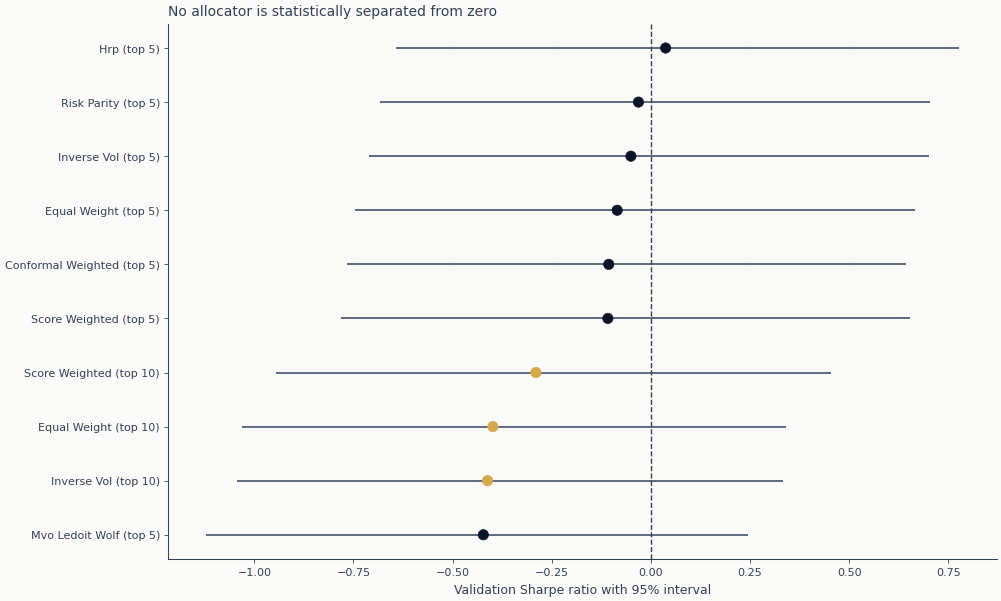

In [16]:
figure_data = leader_lineage.sort("sharpe")
labels = [
    f"{allocator.replace('_', ' ').title()} (top {top_k})"
    for allocator, top_k in figure_data.select("allocator", "allocation_top_k").iter_rows()
]
points = figure_data["sharpe"].to_numpy()
lower = figure_data["sharpe_ci95_lo"].to_numpy()
upper = figure_data["sharpe_ci95_hi"].to_numpy()
errors = np.vstack([points - lower, upper - points])
colors = [
    COLORS["blue"] if top_k == 5 else COLORS["amber"] for top_k in figure_data["allocation_top_k"]
]

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(figure_data))
ax.errorbar(points, y, xerr=errors, fmt="none", ecolor=COLORS["slate"], capsize=3, alpha=0.7)
ax.scatter(points, y, c=colors, s=55, zorder=3)
ax.axvline(0, color=COLORS["neutral"], linewidth=1, linestyle="--")
ax.set_yticks(y, labels)
ax.set_xlabel("Validation Sharpe ratio with 95% interval")
ax.set_title("No allocator is statistically separated from zero")
ax.grid(axis="x", alpha=0.25)
fig.show()

## Key takeaways

1. **Allocation improves the best point estimate.** HRP top-5 lifts the selected 21-day Ridge
   carrier from -0.085 under equal weighting to 0.037, a Sharpe change of +0.122.
2. **The improvement is not statistically resolved.** The HRP leader's 95% interval spans
   -0.643 to 0.777. Allocation does not establish a dependable validation edge.
3. **Concentration helps this thin signal.** The available top-5 variants dominate the top-10
   variants within the leading lineage, consistent with dilution in the broader book.
4. **Selection remains provisional.** Only 9 of 768 latest allocation designs are positive, all
   on the 21-day label. Ch18 must test whether the small point estimate survives cost changes.

**Next:** The costs notebook applies the configured transaction-cost grid to the selected
allocation lineage.